<a href="https://colab.research.google.com/github/pleielp/DL-PyTorch/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D_%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%98_%EA%B5%90%EA%B3%BC%EC%84%9C/06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06-05

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
0
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
전체 샘플의 수 : 1797


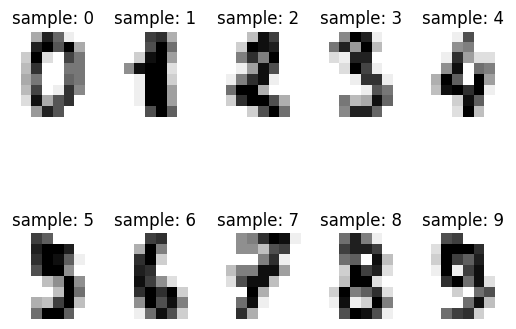

In [ ]:
import matplotlib.pyplot as plt # 시각화를 위한 맷플롯립
from sklearn.datasets import load_digits
digits = load_digits() # 1,979개의 이미지 데이터 로드
print(digits.images[0])
print(digits.target[0])
print(digits.data[0])
print('전체 샘플의 수 : {}'.format(len(digits.images)))

images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:10]): # 5개의 샘플만 출력
    plt.subplot(2, 5, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('sample: %i' % label)

Epoch    0/100 Cost: 2.591872
Epoch   10/100 Cost: 2.111301
Epoch   20/100 Cost: 1.826656
Epoch   30/100 Cost: 1.501712
Epoch   40/100 Cost: 1.138494
Epoch   50/100 Cost: 0.806599
Epoch   60/100 Cost: 0.562710
Epoch   70/100 Cost: 0.404571
Epoch   80/100 Cost: 0.306503
Epoch   90/100 Cost: 0.243716


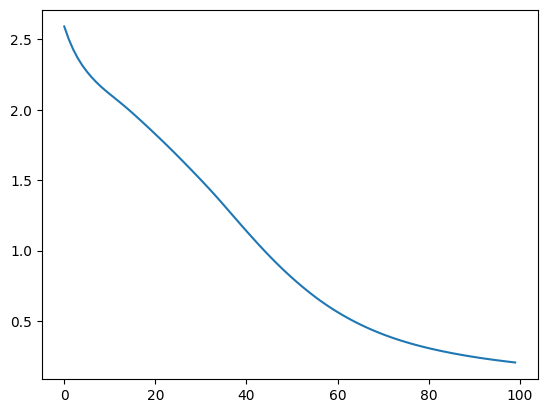

In [ ]:
import torch
import torch.nn as nn
from torch import optim

X = digits.data # 이미지. 즉, 특성 행렬
Y = digits.target # 각 이미지에 대한 레이블

# 입력 데이터 X와 레이블 Y를 텐서로 변환
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.int64)

model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 10),
)

optimizer = optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()

losses = []
# 총 100번의 에포크 동안 모델 학습
for epoch in range(100):
  y_pred = model(X)          # 순전파 연산으로 예측값 계산
  loss = loss_fn(y_pred, Y)  # 손실 함수로 비용 계산

  optimizer.zero_grad()      # 옵티마이저의 기울기 초기화
  loss.backward()            # 역전파 연산으로 기울기 계산
  optimizer.step()           # 옵티마이저를 통해 파라미터 업데이트

  # 10번째 에포크마다 현재 에포크와 손실 값 출력
  if epoch % 10 == 0:
    print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, 100, loss.item()
        ))

  # 손실 값을 리스트에 추가하여 추적
  losses.append(loss.item())

plt.plot(losses)

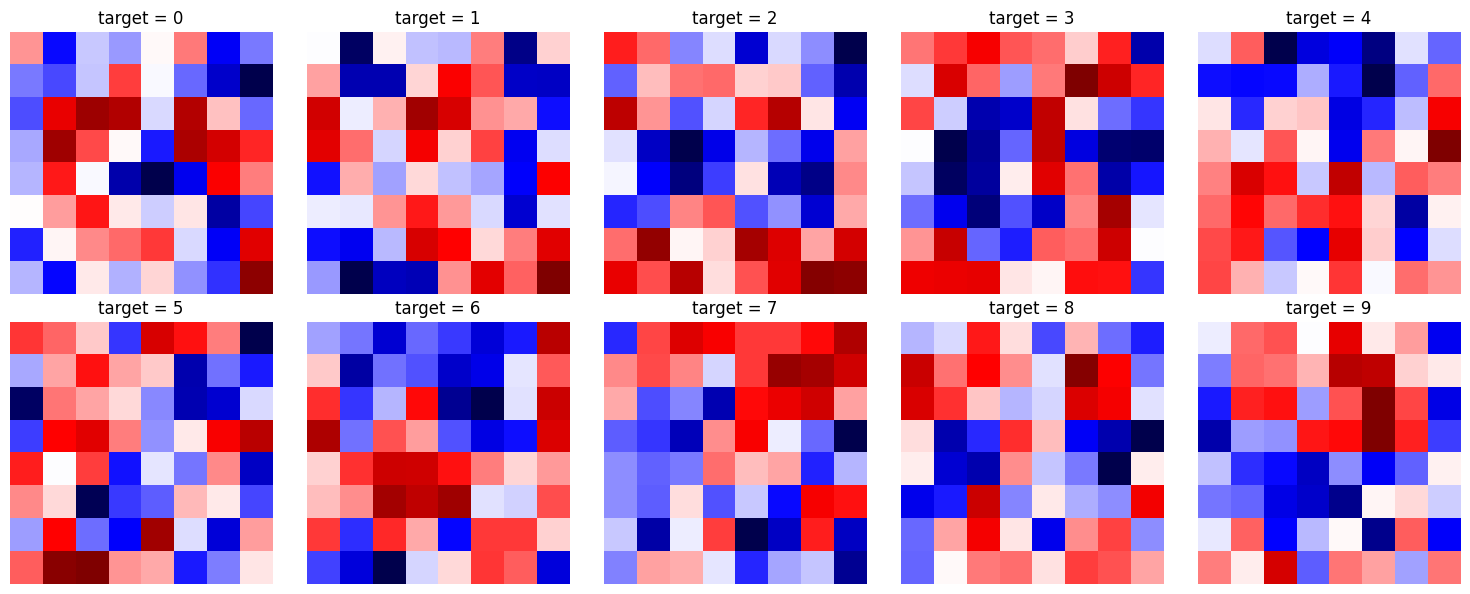

In [ ]:
import numpy as np

w0 = model[0].weight.detach().cpu()  # (32, 64)
w2 = model[2].weight.detach().cpu()  # (16, 32)
w4 = model[4].weight.detach().cpu()  # (10, 16)

# 세 층을 이어붙여 출력→픽셀 유효 가중치 (10, 64)
effective = w4 @ w2 @ w0             # (10, 64)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for target, ax in enumerate(axes.flat):
    img = effective[target].view(8, 8)

    img = (img - img.mean()) / img.std()          # 표준화
    lim = np.percentile(img.abs().numpy(), 98)    # 클리핑

    ax.imshow(img, cmap='seismic', vmin=-lim, vmax=lim)
    ax.set_title(f'target = {target}')
    ax.axis('off')

plt.tight_layout()
plt.show()

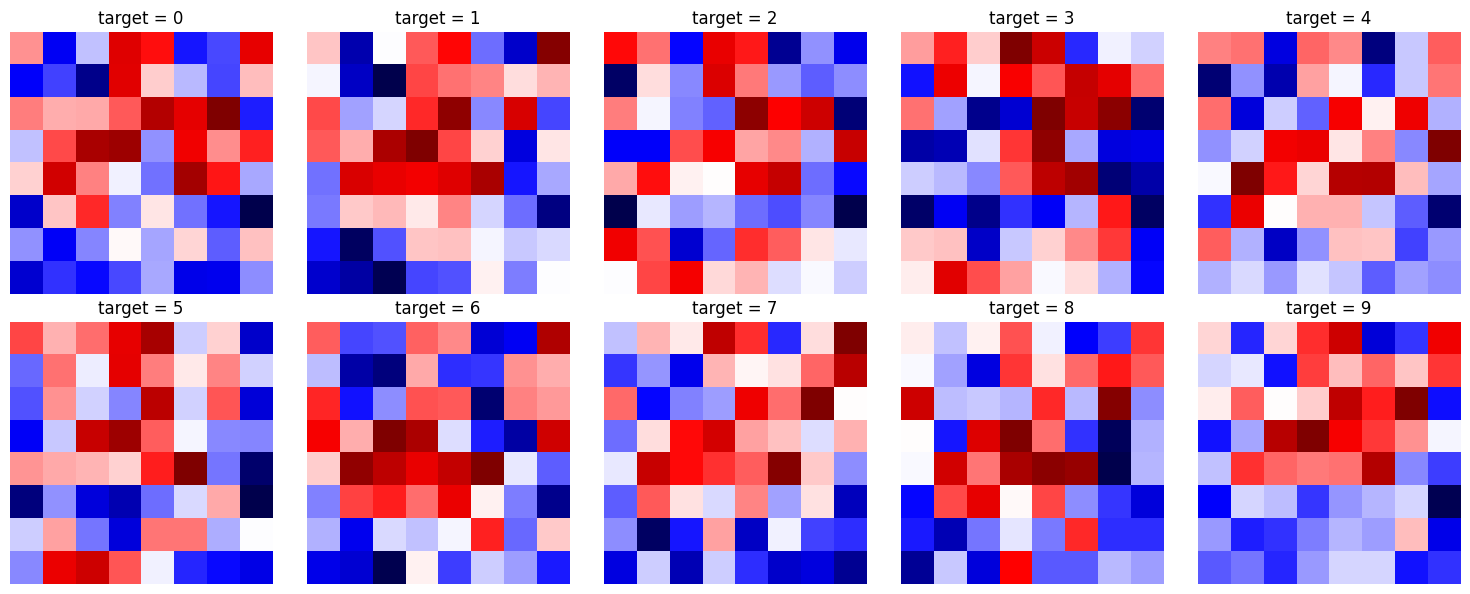

In [ ]:
import numpy as np

w0 = model[0].weight.detach().cpu()  # (32, 64)
w2 = model[2].weight.detach().cpu()  # (16, 32)
w4 = model[4].weight.detach().cpu()  # (10, 16)

N2 = 5   # target이 고를 2번째 은닉 뉴런 수 (16개 중)
N1 = 10  # 각 2번째 뉴런이 고를 1번째 은닉 뉴런 수 (32개 중)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for target, ax in enumerate(axes.flat):
    w0_sum = torch.zeros(64)

    # 1단계: target에 기여 큰 2번째 은닉 뉴런 N2개
    top2 = torch.topk(w4[target], N2).indices.tolist()
    for h2 in top2:
        c2 = w4[target][h2].item()           # target ← h2 기여도

        # 2단계: h2에 기여 큰 1번째 은닉 뉴런 N1개
        top1 = torch.topk(w2[h2], N1).indices.tolist()
        for h1 in top1:
            c1 = w2[h2][h1].item()            # h2 ← h1 기여도
            w0_sum += c2 * c1 * w0[h1]        # 기여도 곱해서 픽셀 패턴 누적

    img = w0_sum.view(8, 8)
    img = (img - img.mean()) / img.std()
    lim = np.percentile(img.abs().numpy(), 98)

    ax.imshow(img, cmap='seismic', vmin=-lim, vmax=lim)
    ax.set_title(f'target = {target}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# 06-06

이 이미지 데이터의 레이블은 5이다


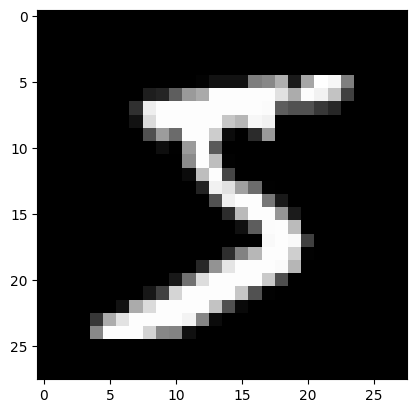

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

X = mnist.data / 255  # 0-255값을 [0,1] 구간으로 정규화
y = mnist.target.astype(np.int8)

plt.imshow(X[0].reshape(28, 28), cmap='gray')
print("이 이미지 데이터의 레이블은 {:.0f}이다".format(y[0]))

In [ ]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

X = mnist.data / 255  # 0-255값을 [0,1] 구간으로 정규화
y = mnist.target.astype(np.int8)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, random_state=0)

# 텐서로 변환
X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# TensorDataset 객체 생성
ds_train = TensorDataset(X_train, y_train)
ds_test = TensorDataset(X_test, y_test)

# DataLoader 객체 생성
loader_train = DataLoader(ds_train, batch_size=64, shuffle=True)
loader_test = DataLoader(ds_test, batch_size=64, shuffle=False)

model = nn.Sequential()
model.add_module('fc1', nn.Linear(28*28*1, 100))
model.add_module('relu1', nn.ReLU())
model.add_module('fc2', nn.Linear(100, 100))
model.add_module('relu2', nn.ReLU())
model.add_module('fc3', nn.Linear(100, 10))

# 가중치를 학습하기 위한 최적화 기법 선택
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 오차함수 선택
loss_fn = nn.CrossEntropyLoss()

# 총 3번의 에포크 동안 모델 학습
epochs = 3
for epoch in range(epochs):
  for data, targets in loader_train:
    y_pred = model(data)          # 순전파 연산으로 예측값 계산
    loss = loss_fn(y_pred, targets)  # 손실 함수로 비용 계산

    optimizer.zero_grad()      # 옵티마이저의 기울기 초기화
    loss.backward()            # 역전파 연산으로 기울기 계산
    optimizer.step()           # 옵티마이저를 통해 파라미터 업데이트

  print('Epoch {:4d}/{} Cost: {:.6f}'.format(epoch + 1, 3, loss.item()))


Epoch    1/3 Cost: 0.030245
Epoch    2/3 Cost: 0.428903
Epoch    3/3 Cost: 0.143149


In [ ]:
model.eval()  # 신경망을 추론 모드로 전환
correct = 0

# 데이터로더에서 미니배치를 하나씩 꺼내 추론을 수행
with torch.no_grad():  # 추론 과정에는 미분이 필요없음
    for data, targets in loader_test:

        outputs = model(data)  # 데이터를 입력하고 출력을 계산

        # 추론 계산
        _, predicted = torch.max(outputs.data, 1)  # 확률이 가장 높은 레이블이 무엇인지 계산
        correct += predicted.eq(targets.data.view_as(predicted)).sum()  # 정답과 일치한 경우 정답 카운트를 증가

# 정확도 출력
data_num = len(loader_test.dataset)  # 데이터 총 건수
print('\n테스트 데이터에서 예측 정확도: {}/{} ({:.0f}%)\n'.format(correct, data_num, 100. * correct / data_num))


테스트 데이터에서 예측 정확도: 9605/10000 (96%)



예측 결과 : 2
이 이미지 데이터의 정답 레이블은 2입니다


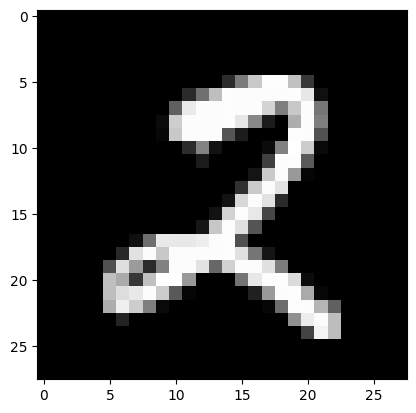

In [ ]:
index = 2018

model.eval()  # 신경망을 추론 모드로 전환
data = X_test[index]
output = model(data)  # 데이터를 입력하고 출력을 계산
_, predicted = torch.max(output.data, 0)  # 확률이 가장 높은 레이블이 무엇인지 계산

print("예측 결과 : {}".format(predicted))

X_test_show = (X_test[index]).numpy()
plt.imshow(X_test_show.reshape(28, 28), cmap='gray')
print("이 이미지 데이터의 정답 레이블은 {:.0f}입니다".format(y_test[index]))

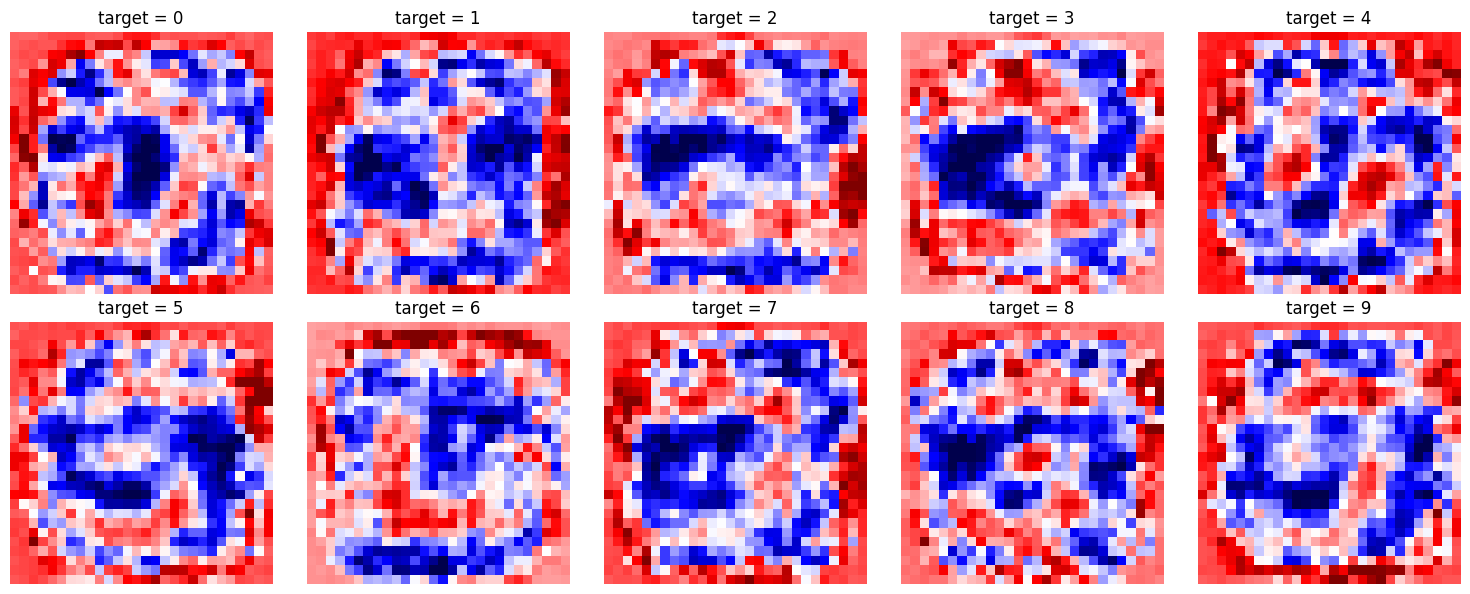

In [ ]:
import numpy as np

w0 = model[0].weight.detach().cpu()  # (724, 100)
w2 = model[2].weight.detach().cpu()  # (100, 100)
w4 = model[4].weight.detach().cpu()  # (100, 10)

# 세 층을 이어붙여 출력→픽셀 유효 가중치 (10, 724)
effective = w4 @ w2 @ w0             # (10, 724)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for target, ax in enumerate(axes.flat):
    img = effective[target].view(28, 28)

    img = (img - img.mean()) / img.std()          # 표준화
    lim = np.percentile(img.abs().numpy(), 98)    # 클리핑

    ax.imshow(img, cmap='seismic', vmin=-lim, vmax=lim)
    ax.set_title(f'target = {target}')
    ax.axis('off')

plt.tight_layout()
plt.show()

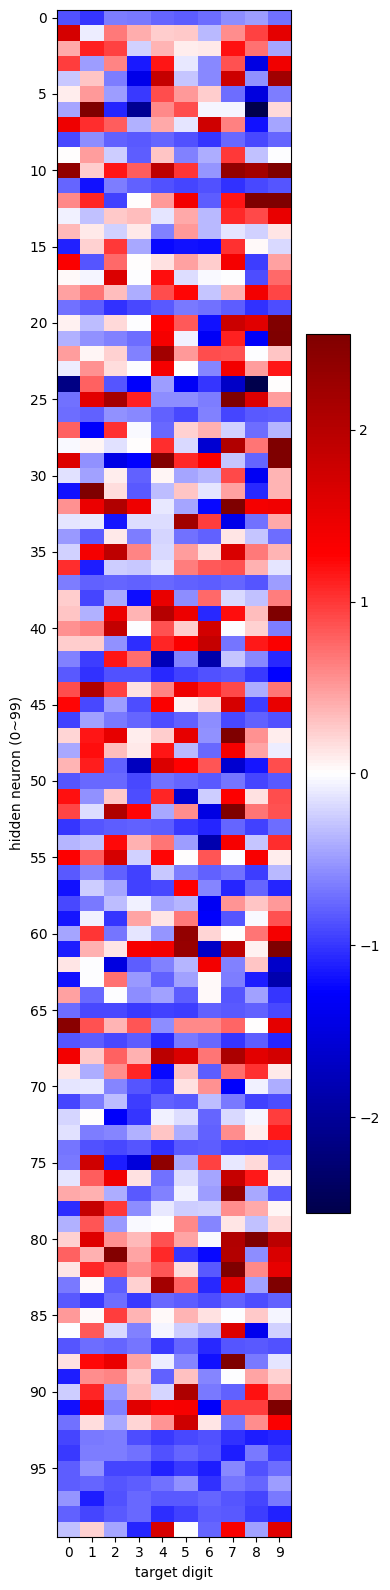

In [ ]:
import numpy as np

w2 = model[2].weight.detach().cpu()  # (100, 100)
w4 = model[4].weight.detach().cpu()  # (100, 10)

# 세 층을 이어붙여 출력→픽셀 유효 가중치 (10, 724)
effective = w4 @ w2             # (10, 100)

# 행(숫자)별로 표준화해서 비교 가능하게
img = (effective - effective.mean()) / effective.std()
img = img.T                           # 전치: (100, 10) — 행=뉴런, 열=숫자
lim = np.percentile(img.abs().numpy(), 98)

fig, ax = plt.subplots(figsize=(4, 16))
im = ax.imshow(img, cmap='seismic', vmin=-lim, vmax=lim, aspect='auto')

ax.set_xlabel('target digit')
ax.set_ylabel('hidden neuron (0~99)')
ax.set_xticks(range(10))
ax.set_yticks(range(0, 100, 5))
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# 06-08

In [3]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(4, 2),
)

# 각 Linear 층에 세이비어 초기화 적용
for layer in model:
    if isinstance(layer, nn.Linear):
        # nn.init.xavier_uniform_(layer.weight)   # 균등분포 버전
        nn.init.xavier_normal_(layer.weight)   # 정규분포 버전
        nn.init.zeros_(layer.bias)              # 편향은 0으로

print(model)
print(model[0])
print(model[0].weight)

Sequential(
  (0): Linear(in_features=4, out_features=2, bias=True)
)
Linear(in_features=4, out_features=2, bias=True)
Parameter containing:
tensor([[-0.4226,  0.1880, -0.0694, -0.0553],
        [-0.2250, -0.4211,  0.3994, -0.0821]], requires_grad=True)
